In [1]:
import IJulia
import Base64

# The julia kernel has built in support for Revise.jl, so this is the 
# recommended approach for long-running sessions:
# https://github.com/JuliaLang/IJulia.jl/blob/9b10fa9b879574bbf720f5285029e07758e50a5e/src/kernel.jl#L46-L51

# Users should enable revise within .julia/config/startup_ijulia.jl:
# https://timholy.github.io/Revise.jl/stable/config/#Using-Revise-automatically-within-Jupyter/IJulia-1

# clear console history
IJulia.clear_history()

fig_width = 5.5
fig_height = 3.5
fig_format = :png
fig_dpi = 300

# no retina format type, use svg for high quality type/marks
if fig_format == :retina
  fig_format = :svg
elseif fig_format == :pdf
  fig_dpi = 96
  # Enable PDF support for IJulia
  IJulia.register_mime(MIME("application/pdf"))
end

# convert inches to pixels
fig_width = fig_width * fig_dpi
fig_height = fig_height * fig_dpi

# Intialize Plots w/ default fig width/height
try
  import Plots

  # Plots.jl doesn't support PDF output for versions < 1.28.1
  # so use png (if the DPI remains the default of 300 then set to 96)
  if (Plots._current_plots_version < v"1.28.1") & (fig_format == :pdf)
    Plots.gr(size=(fig_width, fig_height), fmt = :png, dpi = fig_dpi)
  else
    Plots.gr(size=(fig_width, fig_height), fmt = fig_format, dpi = fig_dpi)
  end
catch e
  # @warn "Plots init" exception=(e, catch_backtrace())
end

# Initialize CairoMakie with default fig width/height
try
  import CairoMakie

  # CairoMakie's display() in PDF format opens an interactive window
  # instead of saving to the ipynb file, so we don't do that.
  # https://github.com/quarto-dev/quarto-cli/issues/7548
  if fig_format == :pdf
    CairoMakie.activate!(type = "png")
  else
    CairoMakie.activate!(type = string(fig_format))
  end
  CairoMakie.update_theme!(resolution=(fig_width, fig_height))
catch e
    # @warn "CairoMakie init" exception=(e, catch_backtrace())
end
  
# Set run_path if specified
try
  run_path = "L3J1bi9tZWRpYS9hbGYvZGF0b3MvbWlzcmVwb3NpdG9yaW9zL2RvY2VuY2lhL2VjdWFjaW9uZXMtZGlmZXJlbmNpYWxlcy1wcmFjdGljYXMtanVsaWE="
  if !isempty(run_path)
    run_path = String(Base64.base64decode(run_path))
    cd(run_path)
  end
catch e
  @warn "Run path init:" exception=(e, catch_backtrace())
end


# emulate old Pkg.installed beahvior, see
# https://discourse.julialang.org/t/how-to-use-pkg-dependencies-instead-of-pkg-installed/36416/9
import Pkg
function isinstalled(pkg::String)
  any(x -> x.name == pkg && x.is_direct_dep, values(Pkg.dependencies()))
end

# ojs_define
if isinstalled("JSON") && isinstalled("DataFrames")
  import JSON, DataFrames
  global function ojs_define(; kwargs...)
    convert(x) = x
    convert(x::DataFrames.AbstractDataFrame) = Tables.rows(x)
    content = Dict("contents" => [Dict("name" => k, "value" => convert(v)) for (k, v) in kwargs])
    tag = "<script type='ojs-define'>$(JSON.json(content))</script>"
    IJulia.display(MIME("text/html"), tag)
  end
elseif isinstalled("JSON")
  import JSON
  global function ojs_define(; kwargs...)
    content = Dict("contents" => [Dict("name" => k, "value" => v) for (k, v) in kwargs])
    tag = "<script type='ojs-define'>$(JSON.json(content))</script>"
    IJulia.display(MIME("text/html"), tag)
  end
else
  global function ojs_define(; kwargs...)
    @warn "JSON package not available. Please install the JSON.jl package to use ojs_define."
  end
end


# don't return kernel dependencies (b/c Revise should take care of dependencies)
nothing


In [2]:
#| echo: false
#| include: false
packages = ["SymPyPythonCall", "Plots", "LaTeXStrings", "LinearAlgebra", "DifferentialEquations", "DiffEqCallbacks", "SpecialFunctions", "Statistics",]

8-element Vector{String}:
 "SymPyPythonCall"
 "Plots"
 "LaTeXStrings"
 "LinearAlgebra"
 "DifferentialEquations"
 "DiffEqCallbacks"
 "SpecialFunctions"
 "Statistics"

In [3]:
#| echo: false
#| include: false
using Plots
# Plots y Makie generan además una representación text/html con la imagen en base64
# en una sola línea; con figuras grandes esa línea desborda la pila del conversor
# de Quarto a Markdown. La desactivamos y dejamos solo image/png.
Base.showable(::MIME"text/html", ::Plots.Plot) = false

In [4]:
#| echo: false
using Markdown
v = string(VERSION)
Markdown.parse("![](https://img.shields.io/badge/Julia-$(v)-9558B2?logo=julia)")

![](https://img.shields.io/badge/Julia-1.12.6-9558B2?logo=julia)


In [5]:
#| echo: false
using Markdown
v = string(VERSION)
Markdown.parse("**Versión de Julia:** $(v)")

**Versión de Julia:** 1.12.6


In [6]:
#| echo: false
#| include: false
import Pkg
active_project = Base.active_project()
global_env = joinpath(homedir(), ".julia", "environments", "v$(VERSION.major).$(VERSION.minor)", "Project.toml")
Pkg.activate(global_env)

  Activating project at `~/.julia/environments/v1.12`


In [7]:
#| echo: false
Pkg.status(packages)

Status 

`~/.julia/environments/v1.12/Project.toml`
  [459566f4] DiffEqCallbacks v4.18.3
  [0c46a032] DifferentialEquations v8.0.2
  [b964fa9f] LaTeXStrings v1.4.0
  [91a5bcdd] Plots v1.41.6
  [276daf66] SpecialFunctions v2.8.0
  [bc8888f7] SymPyPythonCall v0.5.1
  [37e2e46d] LinearAlgebra v1.12.0


In [8]:
#| echo: false
#| include: false
#Pkg.activate(active_project)

In [9]:
β, γ = 0.5, 0.2
R0 = β / γ
pc = 1 - 1/R0
(R0 = R0, umbral_rebaño = pc)

(R0 = 2.5, umbral_rebaño = 0.6)

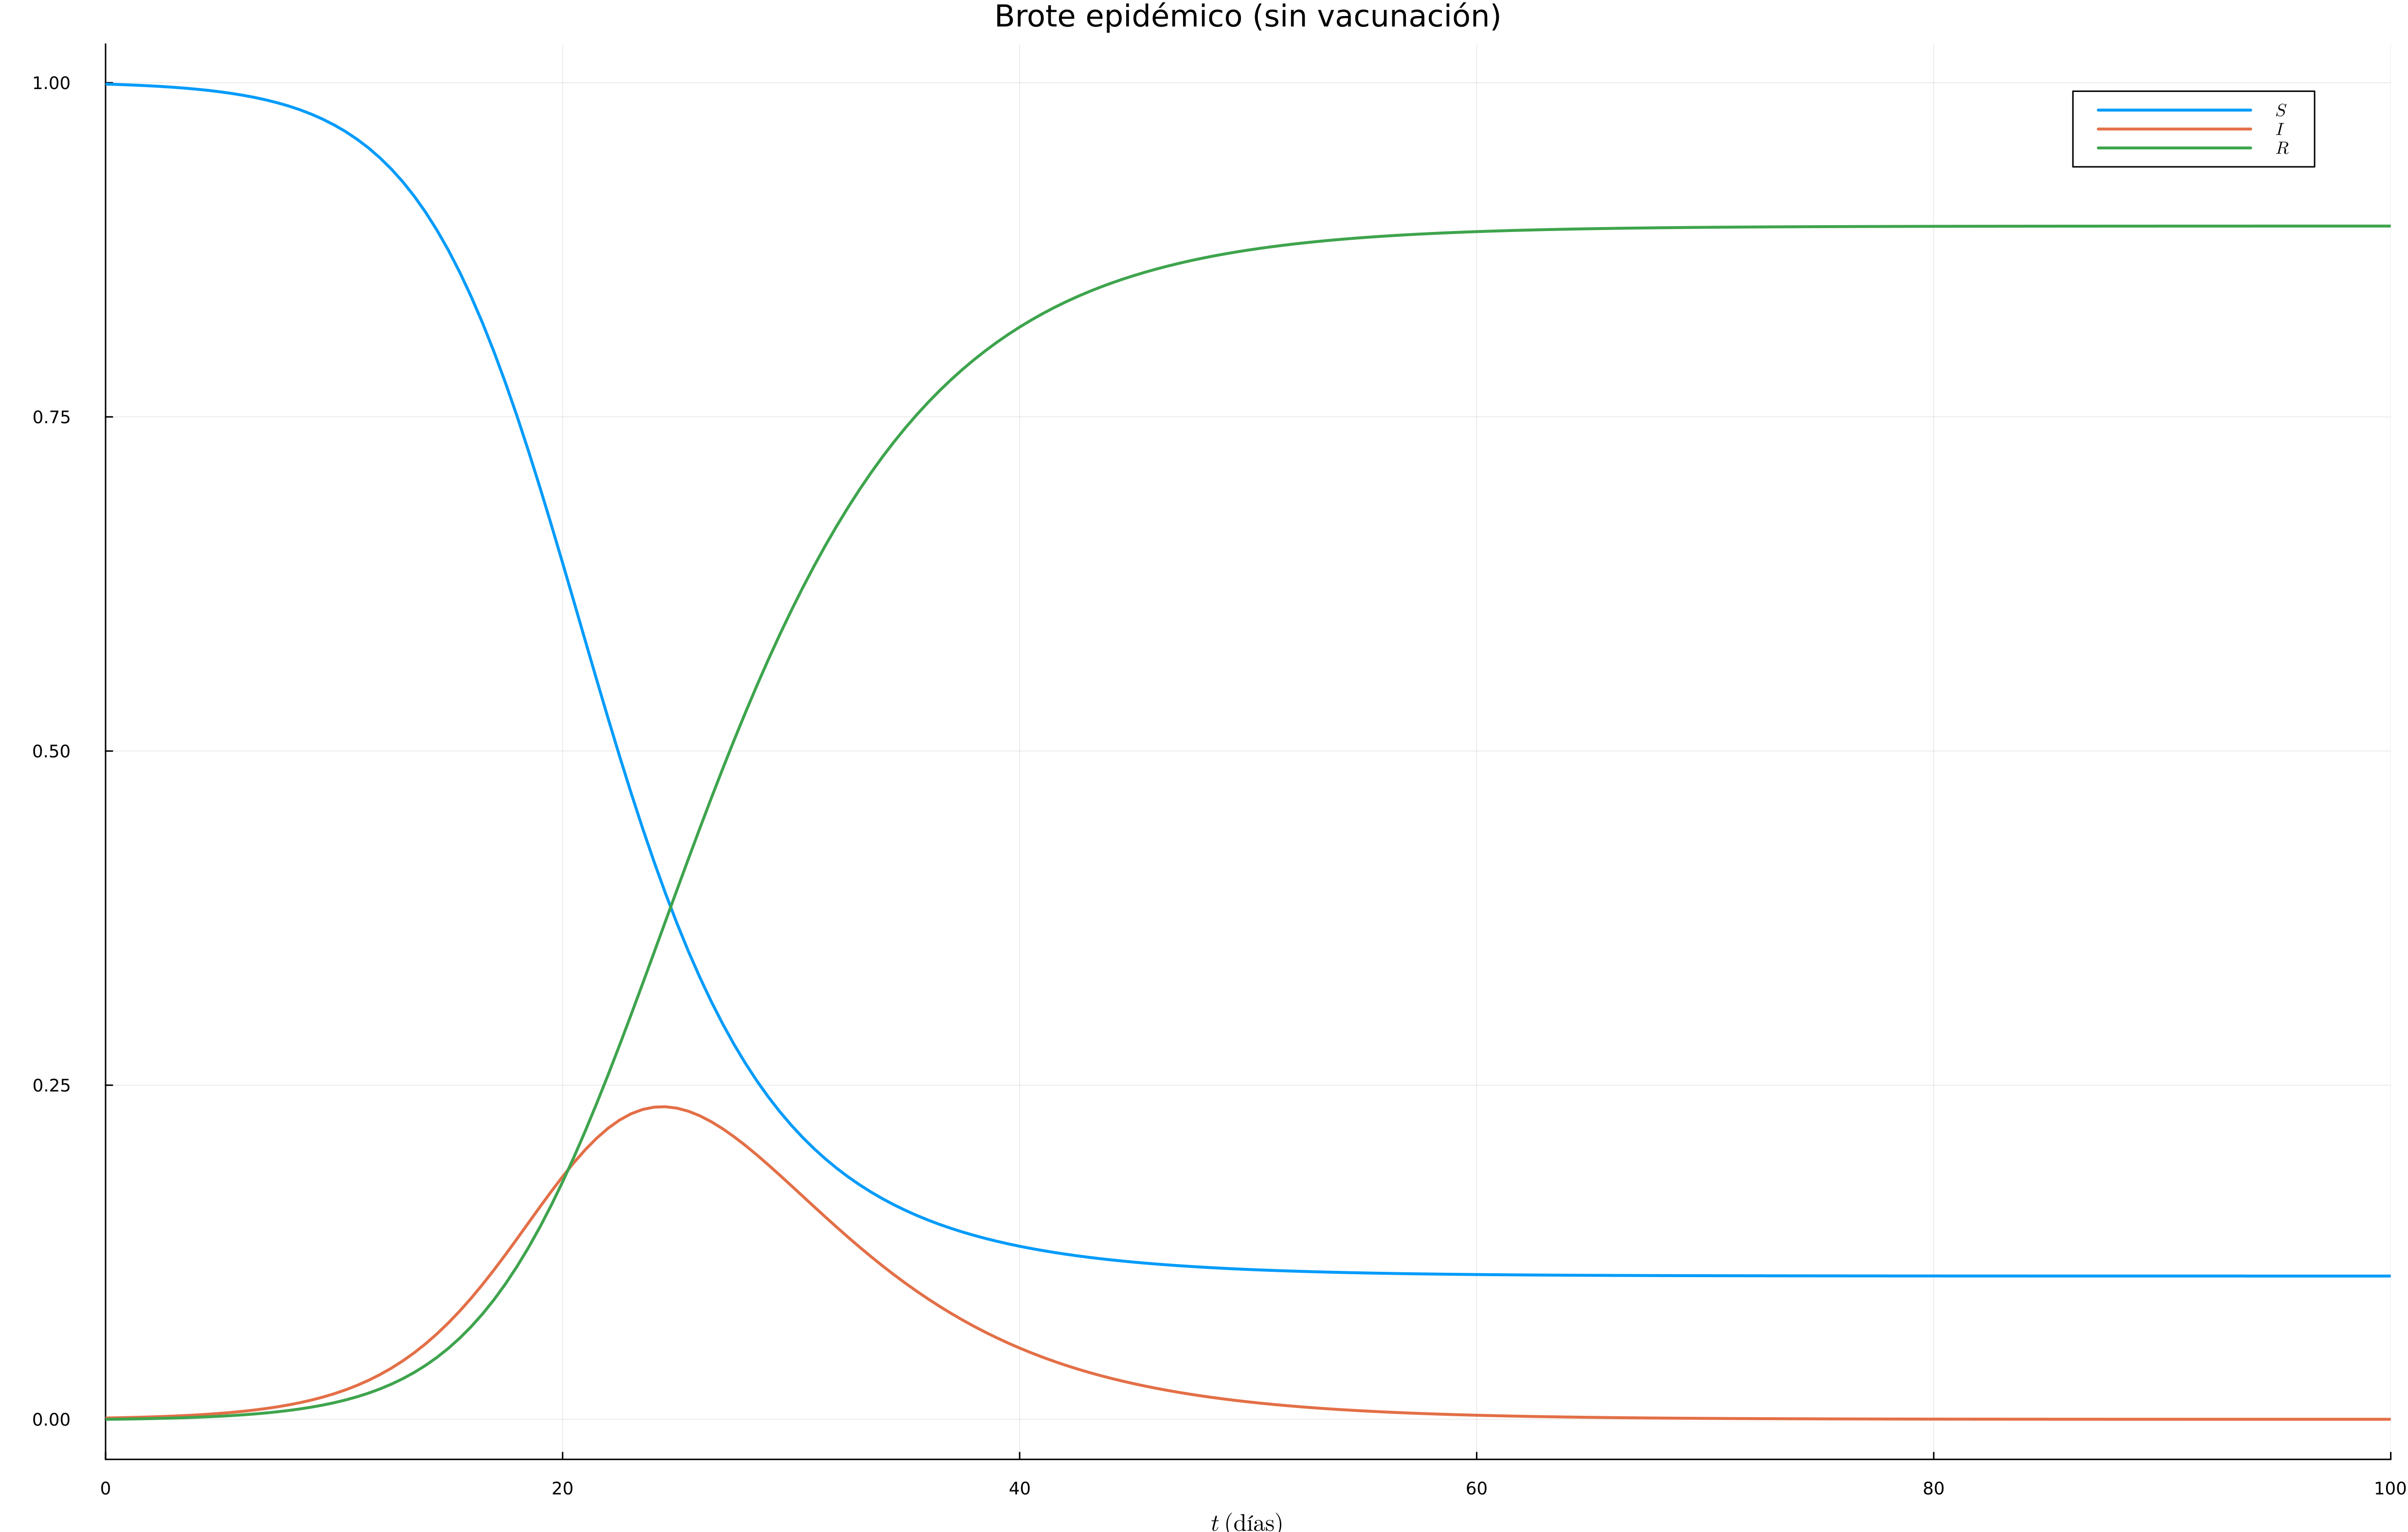

In [10]:
using Plots, LaTeXStrings, DifferentialEquations

function sir!(du, u, p, t)
    S, I, R = u
    β, γ = p
    du[1] = -β * S * I
    du[2] =  β * S * I - γ * I
    du[3] =  γ * I
end

u0 = [0.999, 0.001, 0.0]
prob = ODEProblem(sir!, u0, (0.0, 100.0), (β, γ))
sol = solve(prob, Tsit5(), saveat = 0.5)

plot(sol, label = [L"S" L"I" L"R"], lw = 2,
     xlabel = L"t\ \mathrm{(días)}", ylabel = "Fracción de población",
     title = "Brote epidémico (sin vacunación)")

In [11]:
p_vac = 0.7
u0v = [1 - p_vac - 0.001, 0.001, p_vac]   # vacunados pasan a R
solv = solve(ODEProblem(sir!, u0v, (0.0, 100.0), (β, γ)), Tsit5(), saveat = 0.5)

Imax_sin = maximum(sol[2, :])
Imax_con = maximum(solv[2, :])
(pico_sin_vacuna = Imax_sin, pico_con_vacuna = Imax_con)

(pico_sin_vacuna = 0.23386388754390816, pico_con_vacuna = 0.001)

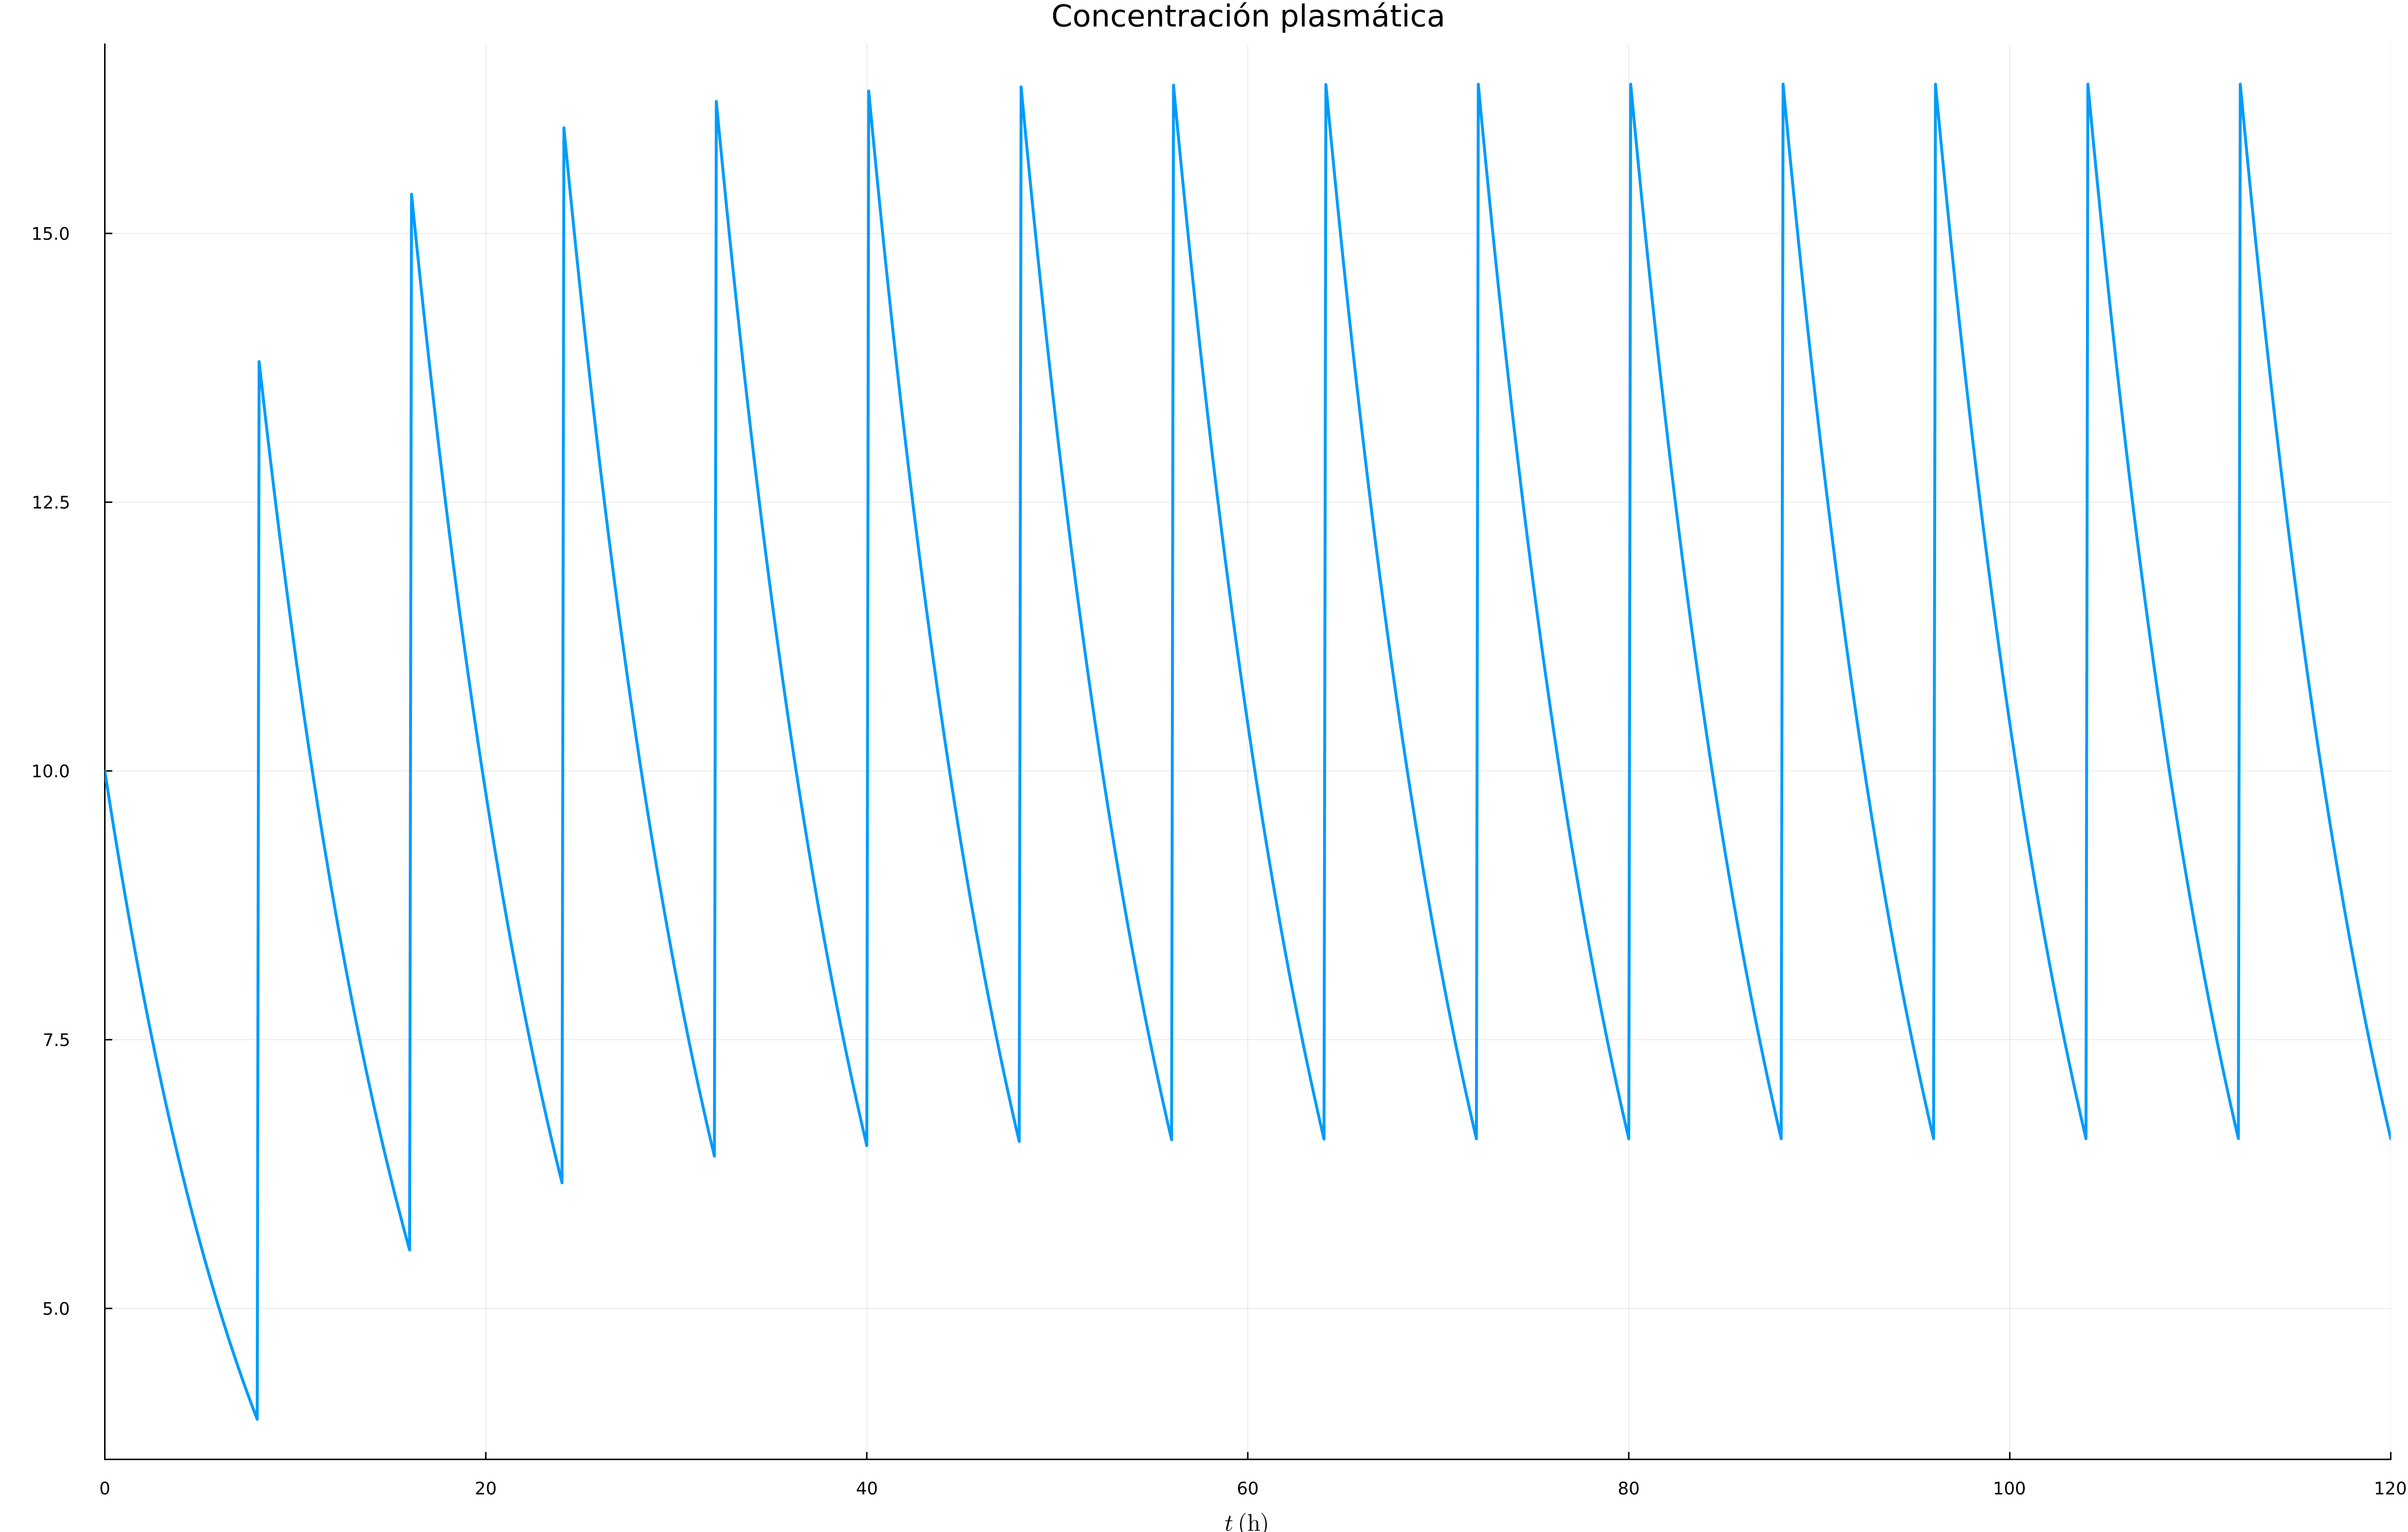

In [12]:
using Plots, LaTeXStrings, DifferentialEquations, DiffEqCallbacks
t_medio = 6.0
k = log(2) / t_medio
C_D, τ = 10.0, 8.0

tiempos_dosis = τ:τ:120.0
afecta!(integrator) = integrator.u[1] += C_D
cb = PresetTimeCallback(collect(tiempos_dosis), afecta!)

pk!(du, u, p, t) = (du[1] = -k * u[1])
probpk = ODEProblem(pk!, [C_D], (0.0, 120.0))
solpk = solve(probpk, Tsit5(), callback = cb, saveat = 0.1)

plot(solpk, label = "", lw = 2, xlabel = L"t\ \mathrm{(h)}",
     ylabel = L"C\ \mathrm{(mg/L)}", title = "Concentración plasmática")

In [13]:
r = exp(-k * τ)                 # fracción que queda tras un intervalo
Cmax_ss = C_D / (1 - r)         # justo tras el bolo
Cmin_ss = Cmax_ss * r           # justo antes del siguiente
acumulacion = 1 / (1 - r)
(Cmax = Cmax_ss, Cmin = Cmin_ss, factor_acumulacion = acumulacion)

(Cmax = 16.579630871775027, Cmin = 6.579630871775029, factor_acumulacion = 1.6579630871775028)

In [14]:
using SymPyPythonCall
@syms x m L θb
θ = θb * cosh(m*(L - x)) / cosh(m*L)
residuo = simplify(diff(θ, x, 2) - m^2 * θ)
(residuo = residuo, base = θ.subs(x, 0), flujo_extremo = diff(θ, x).subs(x, L))

(residuo = 0, base = θb, flujo_extremo = 0)

In [15]:
using Plots, LaTeXStrings

kal, h = 200.0, 25.0
Lf, tf, wf = 0.05, 0.002, 0.03
Ac = wf * tf                     # área de sección
Pf = 2 * (wf + tf)               # perímetro
mval = sqrt(h * Pf / (kal * Ac))
θb_val = 60.0

θfun(x) = θb_val * cosh(mval*(Lf - x)) / cosh(mval*Lf)
xs = range(0, Lf, length = 100)
plot(xs .* 100, θfun.(xs), lw = 2, label = "",
     xlabel = L"x\ \mathrm{(cm)}", ylabel = L"\theta\ \mathrm{(K)}",
     title = "Perfil de temperatura en la aleta")

η = tanh(mval*Lf) / (mval*Lf)          # eficiencia de la aleta
Q = sqrt(h*Pf*kal*Ac) * θb_val * tanh(mval*Lf)   # calor disipado (W)
(m = mval, eficiencia = η, calor_disipado_W = Q)

(m = 11.547005383792516, eficiencia = 0.9019427399712698, calor_disipado_W = 4.329325151862096)

In [16]:
using Statistics
S0, K, r, σ, T = 100.0, 105.0, 0.03, 0.25, 1.0
Nsim = 1_000_000

Z = randn(Nsim)
ST = S0 .* exp.((r - σ^2/2) * T .+ σ * sqrt(T) .* Z)
pagos = max.(ST .- K, 0.0)
precio_mc = exp(-r * T) * mean(pagos)
error_est = exp(-r*T) * std(pagos) / sqrt(Nsim)   # error estándar
(precio_montecarlo = precio_mc, error_estandar = error_est)

(precio_montecarlo = 9.138682367534487, error_estandar = 0.016369652785266923)

In [17]:
using SpecialFunctions
Φ(z) = 0.5 * (1 + erf(z / sqrt(2)))     # función de distribución normal
d1 = (log(S0/K) + (r + σ^2/2)*T) / (σ*sqrt(T))
d2 = d1 - σ*sqrt(T)
precio_bs = S0 * Φ(d1) - K * exp(-r*T) * Φ(d2)
(Black_Scholes = precio_bs, MonteCarlo = precio_mc)

(Black_Scholes = 9.121799457724087, MonteCarlo = 9.138682367534487)

In [18]:
a, b, c, d, λ = 100.0, 2.0, 20.0, 3.0, 0.5
p_eq = (a - c) / (b + d)
tasa = -λ * (b + d)          # autovalor de la linealización
(precio_equilibrio = p_eq, autovalor = tasa)

(precio_equilibrio = 16.0, autovalor = -2.5)

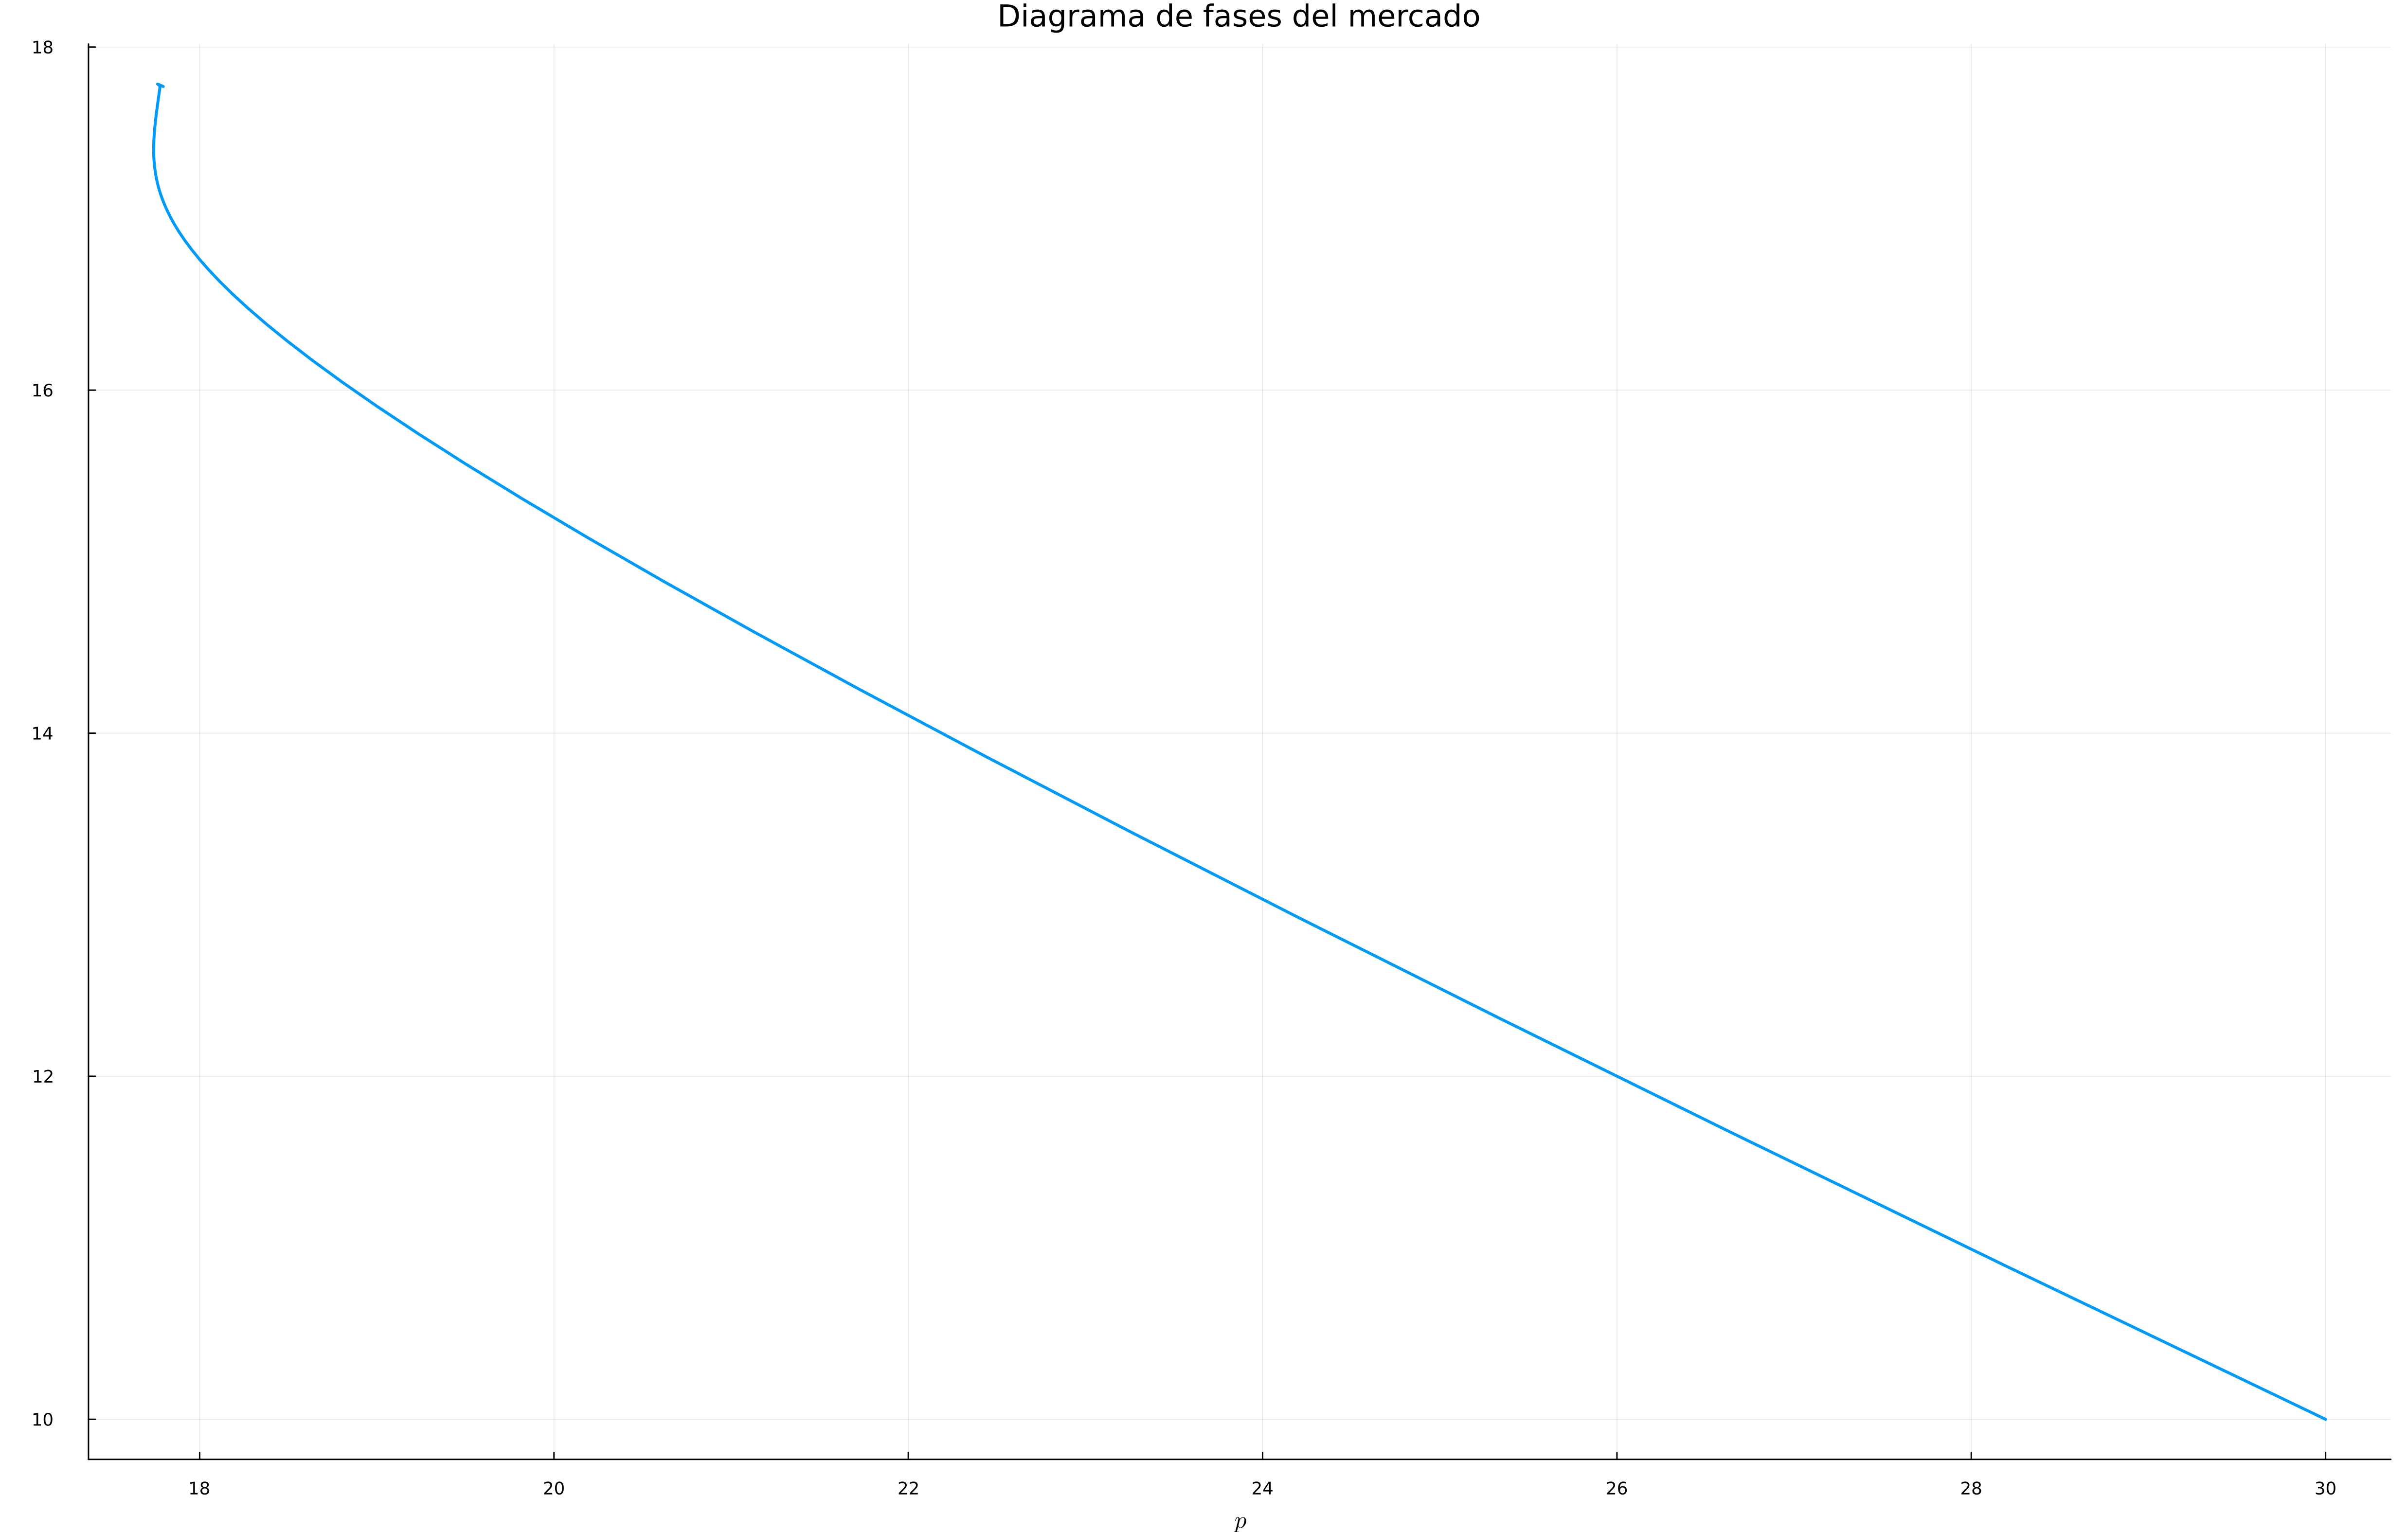

In [19]:
using LinearAlgebra, Plots, LaTeXStrings, DifferentialEquations
μ = 0.8
function mercado!(du, u, pr, t)
    p, q = u
    du[1] = λ * ((a - b*p + 0.5*q) - (c + d*p))   # exceso de demanda
    du[2] = μ * (p - q)                            # ajuste de expectativas
end

J = [-λ*(b+d)  0.5λ; μ  -μ]        # matriz jacobiana del sistema
vals = eigvals(J)

sol = solve(ODEProblem(mercado!, [30.0, 10.0], (0.0, 60.0)), Tsit5())
plot(sol, idxs = (1, 2), lw = 2, label = "",
     xlabel = L"p", ylabel = L"q", title = "Diagrama de fases del mercado")

In [20]:
(autovalores = vals, parte_real = real.(vals), parte_imag = imag.(vals))

(autovalores = [-2.6104686356149274, -0.6895313643850727], parte_real = [-2.6104686356149274, -0.6895313643850727], parte_imag = [0.0, 0.0])